# Evaluation

<a target="_blank" href="https://colab.research.google.com/github/pleyad/Summer-School-2026/blob/main/notebooks/XX_evaluation.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Housekeeping

In [ ]:
%pip install scikit-learn seaborn

❗ Please restart the kernel/runtime after installing the packages to ensure that all changes take effect.

In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    cohen_kappa_score,
)

In [2]:
IN_COLAB = 'COLAB_RELEASE_TAG' in os.environ
DATA_DIR = Path('/content/drive/MyDrive/ZBSummerSchool26/data') if IN_COLAB else Path('../data')

# TODO: define module number
ZB_MODULE = '06'

## Setup (Interaction required)

In [ ]:
### ⬇️⬇️⬇️ 💽 Adjust here if you want to load the data from your google drive
CORPUS_NAME = "armenpflege"
LOAD_OWN_DATA = True
# LOAD_OWN_DATA = False --- IGNORE ---
YOUR_NAME = "niclas"
SEPARATOR = ";" # Separator for the CSV file, e.g., ";" for semicolon, "," for comma
### ⬆️⬆️⬆️

In [36]:
if IN_COLAB and LOAD_OWN_DATA: # and confirm("Do you want to mount your Google Drive?"):
    from google.colab import drive
    drive.mount('/content/drive')
    os.makedirs(DATA_DIR, exist_ok=True)

## Load the data

Dieses Notebook erwartet zwei Dateien mit je den Spalten `id` und `label`:

| Datei | Inhalt |
|---|---|
| `{CORPUS_NAME}.gold.csv` | Menschliche Annotationen aus LabelStudio (Gold Standard) |
| `{CORPUS_NAME}.predictions.csv` | Automatische Labels des LLM aus `XX_Labeling` |

Falls eure Dateien andere Spaltennamen verwenden, bitte oben die Konfiguration anpassen oder die Spalten nach dem Laden umbenennen.

#### <img src="https://cdn.svglogos.dev/logos/google-drive.svg" alt="💾" width=16> Load your own data from Google Drive

In [ ]:
# TODO: define paths
if LOAD_OWN_DATA:
    GOLD_PATH = DATA_DIR / f"{CORPUS_NAME}.filtered.pp.label.{YOUR_NAME}.csv"
    PRED_PATH = DATA_DIR / f"{CORPUS_NAME}.filtered.pp.label.llm.csv"

    gold_df = pd.read_csv(GOLD_PATH, index_col="id", sep=SEPARATOR)
    pred_df = pd.read_csv(PRED_PATH, index_col="id", sep=SEPARATOR)

    print(f'{"Gold standard loaded:":<21} {len(gold_df)} entries')
    print(f'{"Predictions loaded:":<21} {len(pred_df)} entries')
    
    if len(gold_df) != len(pred_df):
        print(f'\n⚠️  Warning: Gold standard and predictions have different lengths!')
        print(f'{"":>4}{"Difference:":<12} {abs(len(gold_df) - len(pred_df))} entries')
    
    display(gold_df.head(3))
    display(pred_df.head(3))

Gold standard loaded: 10 entries
Predictions loaded:   10 entries


,id,label
0,1,ABC
1,2,ABC
2,3,XYZ


,id,label
0,1,ABC
1,2,XYZ
2,3,XYZ


#### <img src="https://cdn.simpleicons.org/github" alt="🏫" width=16> Load Data from Github

In [34]:
if not LOAD_OWN_DATA:
    # TODO: Replace with actual GitHub URLs once example files are published
    GOLD_URL = f'https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/{CORPUS_NAME}.gold.csv'
    PRED_URL = f'https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/{CORPUS_NAME}.predictions.csv'

    print('Loading gold standard ...', end='\r')
    gold_df = pd.read_csv(GOLD_URL)
    print('Loading predictions   ...', end='\r')
    pred_df = pd.read_csv(PRED_URL)

    print(f'{"Gold standard loaded:":<21} {len(gold_df)} entries')
    print(f'{"Predictions loaded:":<21} {len(pred_df)} entries')
    
    if len(gold_df) != len(pred_df):
        print(f'\n⚠️  Warning: Gold standard and predictions have different lengths!')
        print(f'{"":>4}{"Difference:":<12} {abs(len(gold_df) - len(pred_df))} entries')
    
    display(gold_df.head(3))
    display(pred_df.head(3))

HTTPError: HTTP Error 404: Not Found

## Vorbereitung: Merge der DataFrames

Wir verbinden Gold Standard und Predictions über die `id`-Spalte. Da jede Textpassage genau ein Label hat, verwenden wir einen **Inner Join**.

Falls die Anzahl Dokumente vor und nach dem Merge nicht übereinstimmt, fehlt für einige IDs entweder eine Annotation oder eine Prediction.

In [46]:
eval_df = (
    gold_df.rename(columns={'label': 'gold'})
    .merge(pred_df.rename(columns={'label': 'pred'}), on='id', how='inner')
)

print(f'{"Gold standard entries:":<23} {len(gold_df)}')
print(f'{"Predictions entries:":<23} {len(pred_df)}')
print(f'{"Entries after merge:":<23} {len(eval_df)}')
display(eval_df.head(3))

Gold standard entries:  10
Predictions entries:    10
Entries after merge:    10


,id,gold,pred
0,1,ABC,ABC
1,2,ABC,XYZ
2,3,XYZ,XYZ


## Diagnose: Unbekannte Prediction-Labels

LLMs können Labels "halluzinieren" — Kategorien erfinden, die im menschlichen Annotation-Schema nicht vorkommen. Solche Fälle sind ein qualitativer Hinweis auf Modell- oder Prompt-Probleme.

Unbekannte Labels zählen als **False Negative der jeweiligen Gold-Klasse**: Das Modell hat die korrekte Klasse verfehlt. Sie werden auf den Platzhalter `'[unbekannt]'` gemappt, damit sie in der Metrik-Berechnung korrekt berücksichtigt werden.

> **Technische Hintergrundinformation:** `sklearn` würde Instanzen mit unbekannten Prediction-Labels
> stillschweigend verwerfen, wenn man nur die Gold-Klassen als `labels` übergibt. Der False Negative
> für die Gold-Klasse würde damit nicht gezählt — das wäre falsch. Durch den Sentinel als zusätzliche
> Klasse bleiben alle Instanzen im Datensatz erhalten.

In [ ]:
UNKNOWN_LABEL = '[UNK]'  # Placeholder for prediction labels not in the gold standard

In [47]:
gold_label_list = sorted(eval_df['gold'].unique())
unknown = set(eval_df['pred'].unique()) - set(gold_label_list)

if unknown:
    n_affected = eval_df['pred'].isin(unknown).sum()
    print(f'⚠  Labels in Predictions, die nicht im Gold Standard vorkommen: {unknown}')
    print(f'   Anzahl betroffener Dokumente: {n_affected}')
    print(f"   Diese werden auf '{UNKNOWN_SENTINEL}' gemappt")
    print(f'   und zählen als False Negative der jeweiligen Gold-Klasse.')
else:
    print('✓  Alle Prediction-Labels sind im Gold Standard bekannt.')

# Mapping: unbekannte Labels → Sentinel
eval_df['pred_mapped'] = eval_df['pred'].apply(
    lambda x: x if x in gold_label_list else UNKNOWN_SENTINEL
)

# Labels für sklearn: Gold-Klassen + Sentinel (nur wenn er tatsächlich vorkommt)
has_unknown = UNKNOWN_SENTINEL in eval_df['pred_mapped'].values
sklearn_labels = gold_label_list + ([UNKNOWN_SENTINEL] if has_unknown else [])

✓  Alle Prediction-Labels sind im Gold Standard bekannt.


## Label-Verteilung im Gold Standard

Bevor wir Metriken berechnen, lohnt es sich, die Verteilung der Labels zu betrachten. Stark unausgeglichene Klassen beeinflussen, wie aussagekräftig verschiedene Metriken sind — dazu mehr im Abschnitt *Recall bei seltenen Labels*.

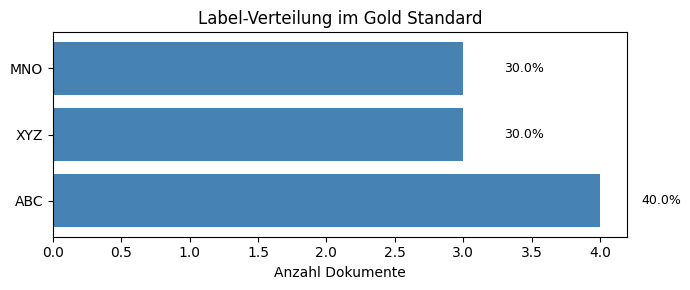

label  count  share
  ABC      4    0.4
  XYZ      3    0.3
  MNO      3    0.3


In [48]:
freq = (
    eval_df['gold']
    .value_counts()
    .rename_axis('label')
    .reset_index(name='count')
)
freq['share'] = freq['count'] / freq['count'].sum()

fig, ax = plt.subplots(figsize=(7, max(3, len(freq) * 0.6)))
bars = ax.barh(freq['label'], freq['count'], color='steelblue')
for bar, share in zip(bars, freq['share']):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{share:.1%}',
        va='center',
        fontsize=9,
    )
ax.set_xlabel('Anzahl Dokumente')
ax.set_title('Label-Verteilung im Gold Standard')
plt.tight_layout()
plt.show()

print(freq.to_string(index=False))

## Metriken

Wir berechnen vier Metriken pro Klasse sowie aggregierte Werte:

| Metrik | Frage |
|---|---|
| **Precision** | Von allen Instanzen, die das Modell als Klasse X klassifiziert hat: wie viele waren tatsächlich X? |
| **Recall** | Von allen Instanzen, die wirklich Klasse X sind: wie viele hat das Modell gefunden? |
| **F1-Score** | Harmonisches Mittel aus Precision und Recall |
| **Accuracy** | Anteil aller korrekt klassifizierten Instanzen |

Die Aggregation **Macro avg** behandelt alle Klassen gleichwertig — auch seltene Klassen zählen gleich viel. **Weighted avg** gewichtet nach Häufigkeit.

**Cohen's κ** misst die Übereinstimmung zwischen Modell und Mensch abzüglich zufälliger Übereinstimmung — robuster als reine Accuracy:
- κ < 0.4: schwache Übereinstimmung
- κ 0.4–0.6: moderate Übereinstimmung  
- κ > 0.8: starke Übereinstimmung

In [49]:
y_true = eval_df['gold']
y_pred = eval_df['pred_mapped']

# sklearn_labels enthält Gold-Klassen + ggf. Sentinel.
# Ohne den Sentinel würde sklearn Instanzen mit unbekannten Predictions
# stillschweigend verwerfen — die False Negatives würden nicht gezählt.
report = classification_report(
    y_true, y_pred,
    labels=sklearn_labels,
    zero_division=0,
    output_dict=True,
)

# Sentinel-Zeile ausblenden — nur Gold-Klassen + Aggregat anzeigen
display_rows = gold_label_list + ['macro avg', 'weighted avg']
report_df = pd.DataFrame(report).T.loc[display_rows]
print(report_df.round(3).to_string())

acc   = accuracy_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)
print(f'\nAccuracy : {acc:.3f}')
print(f"Cohen's κ: {kappa:.3f}")

              precision  recall  f1-score  support
ABC               0.750   0.750     0.750      4.0
MNO               0.667   0.667     0.667      3.0
XYZ               0.667   0.667     0.667      3.0
macro avg         0.694   0.694     0.694     10.0
weighted avg      0.700   0.700     0.700     10.0

Accuracy : 0.700
Cohen's κ: 0.545


## Konfusionsmatrix

Die Konfusionsmatrix zeigt, welche Klassen miteinander verwechselt werden:

- **Zeilen** = Gold Standard (was eine Instanz wirklich ist)
- **Spalten** = Prediction des Modells
- **Diagonale** = korrekte Klassifikationen
- **Ausserhalb der Diagonale** = Fehler — welche Klasse wurde mit welcher verwechselt?

Die **normierte Variante** (rechts) zeigt den Recall je Klasse direkt auf der Diagonalen: Welcher Anteil einer Gold-Klasse wurde korrekt erkannt? Alles ausserhalb — inklusive einer `[unbekannt]`-Spalte, falls das Modell halluziniert hat — sind verfehlte Instanzen (False Negatives).

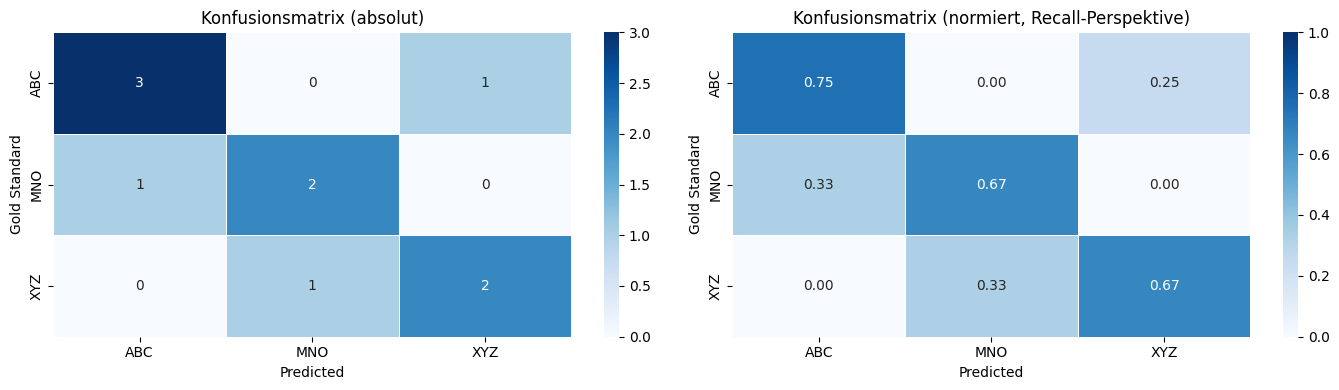

In [50]:
# pd.crosstab zeigt automatisch alle Prediction-Spalten, inkl. [unbekannt] falls vorhanden
cm_df = pd.crosstab(
    eval_df['gold'],
    eval_df['pred_mapped'],
    rownames=['Gold Standard'],
    colnames=['Predicted'],
)

# Alle Gold-Klassen als Zeilen sicherstellen (auch wenn nie vorhergesagt)
cm_df = cm_df.reindex(index=gold_label_list, fill_value=0)

# Spaltenreihenfolge: Gold-Klassen zuerst, Sentinel ans Ende
col_order = [c for c in gold_label_list if c in cm_df.columns]
if UNKNOWN_SENTINEL in cm_df.columns:
    col_order.append(UNKNOWN_SENTINEL)
cm_df = cm_df[col_order]

n_labels = len(gold_label_list)
fig, axes = plt.subplots(1, 2, figsize=(14, max(4, n_labels * 1.2)))

# Absolut
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', ax=axes[0], linewidths=0.5)
axes[0].set_title('Konfusionsmatrix (absolut)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Gold Standard')

# Normiert nach Zeilensumme → Diagonale = Recall je Klasse
cm_norm = cm_df.div(cm_df.sum(axis=1), axis=0).round(2)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            vmin=0, vmax=1, linewidths=0.5)
axes[1].set_title('Konfusionsmatrix (normiert, Recall-Perspektive)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Gold Standard')

plt.tight_layout()
plt.show()

## Recall bei seltenen Labels

Ein häufiges Missverständnis: ein Modell mit hoher **Accuracy** ist automatisch gut. Das stimmt nicht, sobald die Labels ungleich verteilt sind.

**Gedankenexperiment:** Stell dir vor, 95 % aller Dokumente haben das Label `neutral` und nur 5 % das Label `positiv`. Ein Modell, das *immer* `neutral` vorhersagt, erreicht **95 % Accuracy** — und findet trotzdem kein einziges positives Dokument.

> **Accuracy belohnt das häufige Label. Recall schützt das seltene.**

**Recall** fragt: *Von allen Dokumenten, die wirklich das Label X haben — wie viele hat das Modell gefunden?* Bei seltenen Klassen ist das besonders relevant: genau diese Dokumente sind oft die inhaltlich interessantesten Fälle — und werden am leichtesten übersehen.

Der folgende Code demonstriert diesen Effekt mit den echten Daten aus dem Korpus:

In [51]:
# Seltenste Klasse im Gold Standard
rarest = freq.iloc[-1]
rarest_label = rarest['label']
rarest_count = int(rarest['count'])
rarest_share = rarest['share']

r = report_df.loc[rarest_label]

print(f"Seltenste Klasse: '{rarest_label}'")
print(f'  Anzahl Dokumente: {rarest_count} ({rarest_share:.1%} des Korpus)')
print()
print(f"  Precision : {r['precision']:.3f}")
print(f"  Recall    : {r['recall']:.3f}")
print(f"  F1-Score  : {r['f1-score']:.3f}")
print()
print(f'Gesamt-Accuracy: {acc:.3f}')
print()
print('→ Hohe Accuracy kann trotz niedrigem Recall beim seltenen Label auftreten.')
print('→ Macro F1 und Macro Recall gewichten alle Klassen gleichwertig')
print('  und sind daher robustere Metriken bei unausgeglichenen Datensätzen.')

Seltenste Klasse: 'MNO'
  Anzahl Dokumente: 3 (30.0% des Korpus)

  Precision : 0.667
  Recall    : 0.667
  F1-Score  : 0.667

Gesamt-Accuracy: 0.700

→ Hohe Accuracy kann trotz niedrigem Recall beim seltenen Label auftreten.
→ Macro F1 und Macro Recall gewichten alle Klassen gleichwertig
  und sind daher robustere Metriken bei unausgeglichenen Datensätzen.


## Zusammenfassung

In [52]:
summary = pd.DataFrame({
    'Metrik': ['Accuracy', "Cohen's κ", 'Macro Precision', 'Macro Recall', 'Macro F1'],
    'Wert': [
        acc,
        kappa,
        report['macro avg']['precision'],
        report['macro avg']['recall'],
        report['macro avg']['f1-score'],
    ]
})

print(summary.round(3).to_string(index=False))

# Optional: Ergebnisse als CSV speichern
# summary.to_csv(DATA_DIR / f'{CORPUS_NAME}.evaluation_summary.csv', index=False)

         Metrik  Wert
       Accuracy 0.700
      Cohen's κ 0.545
Macro Precision 0.694
   Macro Recall 0.694
       Macro F1 0.694
